# Density-peak clustering of a SAGD matrix

Runs `lib.density_clustering` (Rodriguez & Laio, *Science* 2014) on a cached SAGD
distance matrix and plots the **decision graph**: for every snapshot, the local density
$\rho$ against $\delta$, the distance to the closest snapshot of higher density.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

from lib.density_clustering import (
    density_peaks,
    cluster_sagd_matrix,
    num_cluster_candidates,
    plot_decision_graph,
    plot_gamma_ratio,
    plot_gamma_ratio_gain,
    plot_labels_over_time,
)
from lib.ou_model import find_third_phase_onset
from lib.viz.plotting import plot_sagd_heatmap_with_prob, _draw_sagd_heatmap_with_prob

In [2]:
EXP_DIR = Path("../data/log_scale_and_shift_D256 1024 4096_n4000/D1024_N4000_T10")
D_DIM = int(EXP_DIR.name.split("_")[0][1:])   # the ambient dimension, for the plot title

D = joblib.load(EXP_DIR / "SAGD.jbl")

# Times are not stored in SAGD.jbl; row i of D corresponds to ts[i].
ctds = joblib.load(EXP_DIR / "CTDs.jbl")
ts = np.asarray(ctds["params"]["ts"])

breakpoints = joblib.load(EXP_DIR / "clusters.jbl")
t_sagd = float(ts[breakpoints[0]])
t_star_sagd = find_third_phase_onset(ctds["CTDs"], ts)

MARKERS = {
    r"$t_{SAGD}$": t_sagd,
    r"$t^*_{SAGD}$": t_star_sagd,
}

print(f"SAGD matrix: {D.shape}")
print(f"{len(ts)} snapshots, t = {ts[0]:.3g} -> {ts[-1]:.3g}")
print(f"t_SAGD  = {t_sagd:.3g}   (DP breakpoint {breakpoints[0]})")
print(f"t*_SAGD = {t_star_sagd:.3g}")

SAGD matrix: (233, 233)
233 snapshots, t = 10 -> 0.01
t_SAGD  = 3.03   (DP breakpoint 131)
t*_SAGD = 1.02


## Summary panel for one run

`regime_summary` takes the run itself — `model`, `n_samples`, `dim` — plus the clustering
knobs,
loads the cached run under `DATA_ROOT` and puts the views side by side: decision graph on
the left, the $\gamma$ persistence ratio in the middle with its gain below it, SAGD
matrix top right, density-peak labels underneath it.

The dashed lines are the DP breakpoints of `lib.interval_clustering`.
.
**Choosing $K$.** $k$ can be chosen via elbow method using $\gamma$-ratio

$$\mathrm{ratio}(K) = \frac{\gamma_K}{\gamma_{K+1}}$$

Or local maxima of gap ratio

$$\mathrm{gap ratio}(K) = \frac{\gamma_{K - 1} - \gamma_{K}}{\gamma_{K} - \gamma_{K + 1}}$$


In [3]:
DATA_ROOT = Path("../data")
MAX_CANDIDATE_PLOTS = 5

MODEL_EXP_DIRS = {
    "bimodal": "*_n{n_samples}",
    "hierarchical": "scale_and_shift_log_scale_hierarchical",
}


def load_run(model, n_samples, dim):
    """The SAGD matrix, its snapshot times and its interval-clustering breakpoints.

    `model` picks the experiment directory under `DATA_ROOT` -- see `MODEL_EXP_DIRS`.
    """
    if model not in MODEL_EXP_DIRS:
        raise ValueError(f"model must be one of {sorted(MODEL_EXP_DIRS)}, got {model!r}")

    exp_glob = MODEL_EXP_DIRS[model].format(n_samples=n_samples)
    matches = sorted(DATA_ROOT.glob(f"{exp_glob}/D{dim}_N{n_samples}_T*"))
    if not matches:
        raise FileNotFoundError(
            f"No cached {model} run for D={dim}, N={n_samples} under {DATA_ROOT}"
        )

    exp_dir = matches[0]
    times = np.asarray(joblib.load(exp_dir / "CTDs.jbl")["params"]["ts"])
    sagd = np.asarray(joblib.load(exp_dir / "SAGD.jbl"))
    breakpoints = np.asarray(joblib.load(exp_dir / "clusters.jbl"), dtype=int)

    return sagd, times, breakpoints


def draw_label_strip(ax, labels, times, breakpoints, ax_hm, ylabel, show_xticks):
    """One label-per-snapshot strip, in the heatmap's snapshot-index space."""
    ax.scatter(
        np.arange(times.size) + 0.5, np.zeros(times.size),
        c=labels, cmap="tab10", vmin=0, vmax=9, marker="|", s=400,
    )
    for b in breakpoints:
        ax.axvline(b + 0.5, color="orange", linestyle="--", alpha=0.8,
                   label=f"breakpoint t = {times[b]:.2f}")

    ticks = np.linspace(0, times.size - 1, 8, dtype=int)
    ax.set_xlim(ax_hm.get_xlim())
    ax.set_xticks(ticks + 0.5)
    ax.set_yticks([])
    ax.set_ylabel(ylabel, fontsize=11)

    if show_xticks:
        ax.set_xticklabels([f"{times[i]:.2f}" for i in ticks], rotation=45)
        ax.set_xlabel("Time", fontsize=12)
    else:
        ax.set_xticklabels([])


def regime_summary(model, n_samples, dim, kernel="gaussian", n_clusters=5,
                   to_annotate=10, max_clusters=10, save_path=None):
    """Decision graph, gamma persistence ratio, SAGD matrix and density-peak labels.

    `model` is the data model the run came from -- "bimodal" or "hierarchical".

    With `n_clusters` left unset the cluster counts come from `num_cluster_candidates`
    -- one label strip per candidate, at most MAX_CANDIDATE_PLOTS of them, and the
    decision graph shows the centers of the strongest one.
    """
    sagd, times, breakpoints = load_run(model, n_samples, dim)
    peaks = density_peaks(sagd, n_clusters=n_clusters, kernel=kernel)

    if n_clusters is not None:
        ks = [n_clusters]
    else:
        candidates = num_cluster_candidates(peaks.gamma, max_clusters=max_clusters)
        ks = sorted(int(k) for k in candidates[:MAX_CANDIDATE_PLOTS])
        if ks:
            peaks = density_peaks(sagd, n_clusters=int(candidates[0]), kernel=kernel)
        else:
            ks = [peaks.centers.size]
            print(f"No candidate below K={max_clusters}, "
                  f"falling back to the largest gamma gap (K={ks[0]})")

    fig = plt.figure(figsize=(20, 6.5 + 0.9 * (len(ks) - 1)))
    grid = fig.add_gridspec(
        1 + len(ks), 3,
        width_ratios=[1.0, 0.75, 1.15], height_ratios=[6] + [1] * len(ks),
        hspace=0.15, wspace=0.25,
    )
    ax_dg = fig.add_subplot(grid[:, 0])
    ratio_grid = grid[:, 1].subgridspec(2, 1, hspace=0.45)
    ax_ratio = fig.add_subplot(ratio_grid[0])
    ax_gain = fig.add_subplot(ratio_grid[1])
    ax_hm = fig.add_subplot(grid[0, 2])

    plot_decision_graph(peaks, ts=times, ax=ax_dg, to_annotate=to_annotate)
    ax_dg.set_box_aspect(1)
    plot_gamma_ratio(peaks, max_clusters=max_clusters, ax=ax_ratio,
                     to_annotate=MAX_CANDIDATE_PLOTS)
    plot_gamma_ratio_gain(peaks, max_clusters=max_clusters, ax=ax_gain,
                          to_annotate=MAX_CANDIDATE_PLOTS)

    _draw_sagd_heatmap_with_prob(
        ax_hm=ax_hm, W=sagd, time_vector=times, d=dim, distance="SAGD",
        mu=None, std=None, ts=None, tsagd=None, t_star=None,
        show_prob=False, show_legend=False,
    )
    ax_hm.set_xlabel("")
    ax_hm.set_xticklabels([])

    strips = []
    for row, k in enumerate(ks, start=1):
        ax_lab = fig.add_subplot(grid[row, 2])
        labels = density_peaks(sagd, n_clusters=k, kernel=kernel).labels
        draw_label_strip(ax_lab, labels, times, [], ax_hm,
                         ylabel=f"K={k}", show_xticks=(row == len(ks)))
        strips.append(ax_lab)

    if breakpoints.size:
        strips[0].legend(frameon=False, fontsize=9, loc="upper left",
                         bbox_to_anchor=(1.01, 1.0))

    fig.suptitle(f"model={model}, D={dim}, N={n_samples}, kernel={kernel}", fontsize=14)

    fig.canvas.draw()
    hm_pos = ax_hm.get_position()
    for ax_lab in strips:
        pos = ax_lab.get_position()
        ax_lab.set_position([hm_pos.x0, pos.y0, hm_pos.width, pos.height])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

/home/ivto4984/projects/sagd_regimes/Shape-Aware-Regimes-of-Diffusion-Models/scripts/lib/density_clustering.py:550: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=9)
/tmp/ipykernel_710431/2299453568.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  strips[0].legend(frameon=False, fontsize=9, loc="upper left",


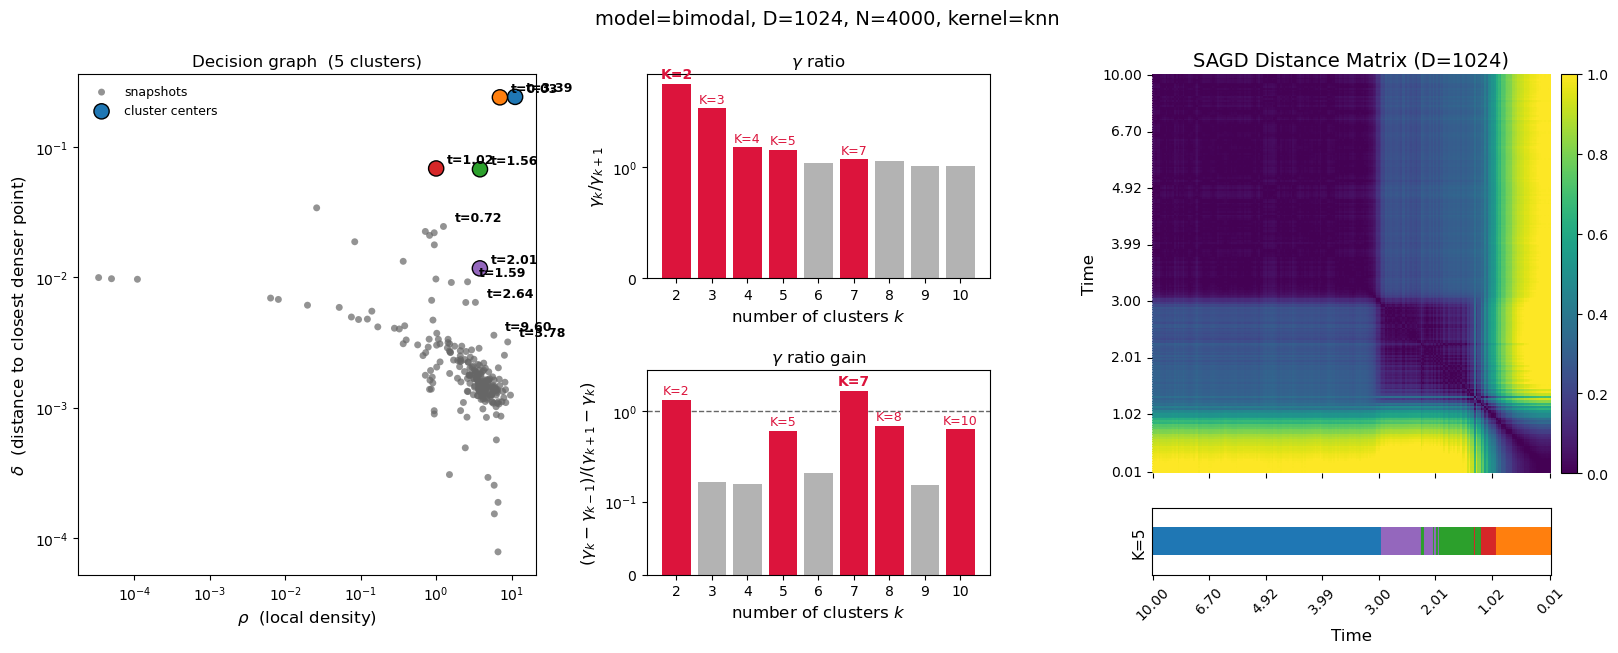

In [4]:
regime_summary(model="bimodal", n_samples=4000, dim=1024, kernel="knn")

### Letting the ratio pick $K$

No `n_clusters`: one strip per candidate, ordered by increasing $K$.

/home/ivto4984/projects/sagd_regimes/Shape-Aware-Regimes-of-Diffusion-Models/scripts/lib/density_clustering.py:550: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=9)
/tmp/ipykernel_710431/2299453568.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  strips[0].legend(frameon=False, fontsize=9, loc="upper left",


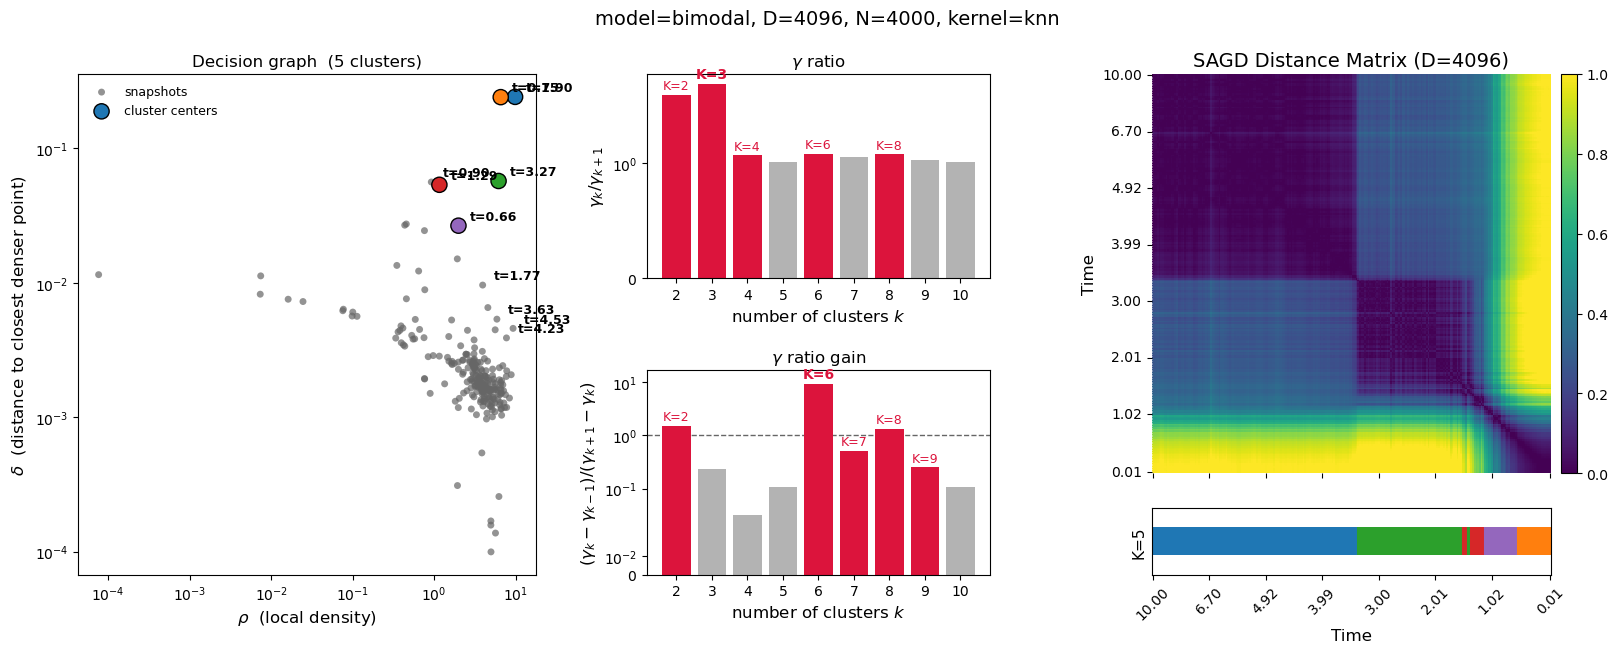

In [5]:
regime_summary(model="bimodal", n_samples=4000, dim=4096, kernel="knn")

### The hierarchical Gaussian


/home/ivto4984/projects/sagd_regimes/Shape-Aware-Regimes-of-Diffusion-Models/scripts/lib/density_clustering.py:550: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=9)


/tmp/ipykernel_710431/2299453568.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  strips[0].legend(frameon=False, fontsize=9, loc="upper left",


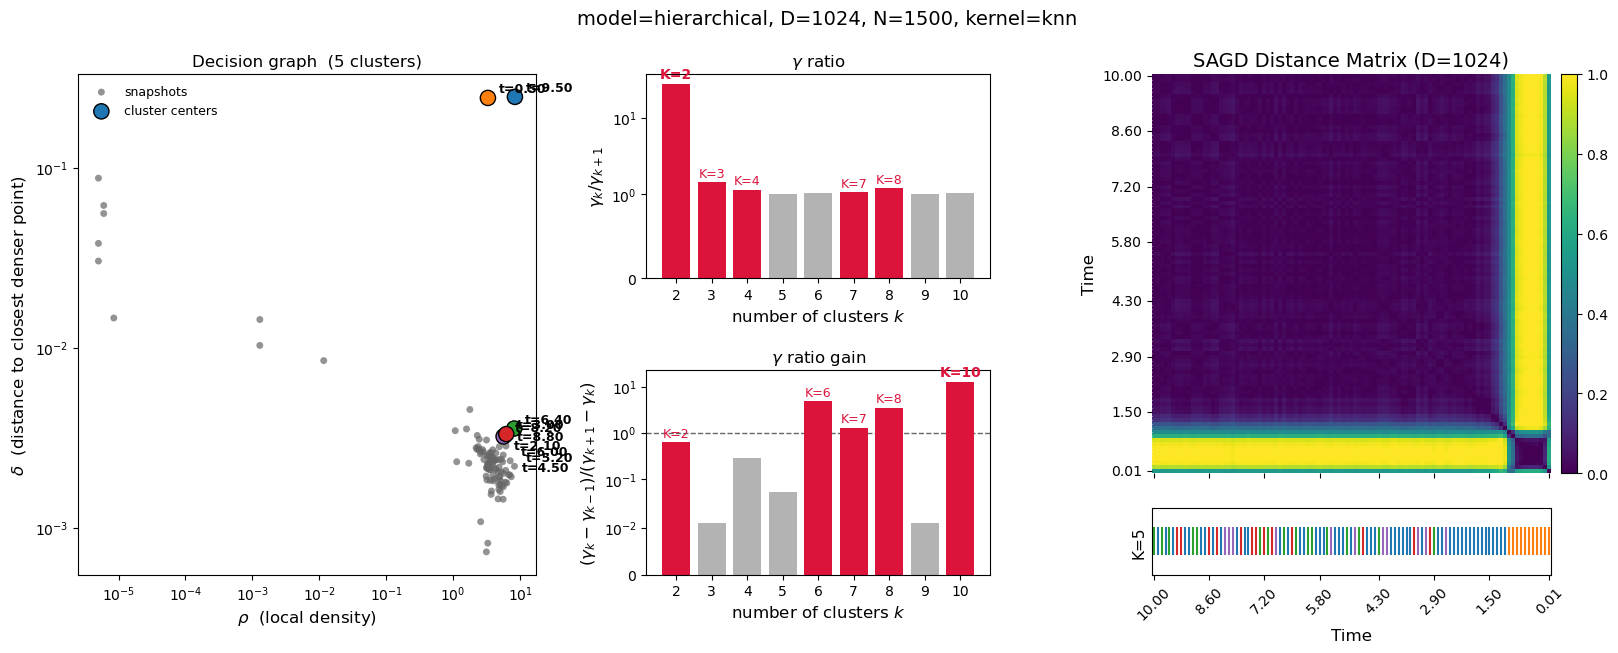

In [6]:
regime_summary(model="hierarchical", n_samples=1500, dim=1024, kernel="knn")

/home/ivto4984/projects/sagd_regimes/Shape-Aware-Regimes-of-Diffusion-Models/scripts/lib/density_clustering.py:550: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=9)
/tmp/ipykernel_710431/2299453568.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  strips[0].legend(frameon=False, fontsize=9, loc="upper left",


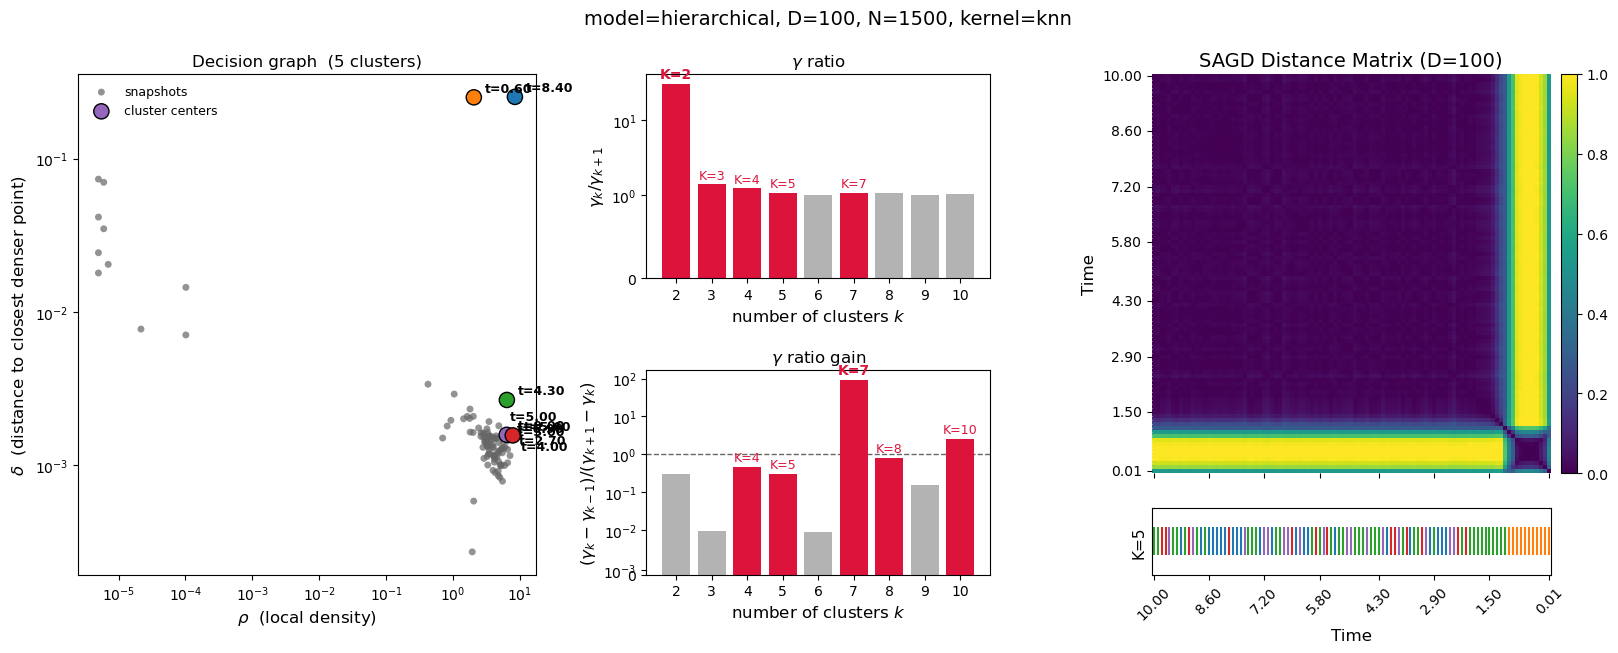

In [7]:
regime_summary(model="hierarchical", n_samples=1500, dim=100, kernel="knn")